In [1]:
import shutil
import os
import sys

In [2]:
shutil.which("dggrid")

'/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/bin/dggrid'

In [3]:
os.environ["DGGRID_PATH"]

'/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/bin/dggrid'

In [4]:
dggrid_exec = os.environ["DGGRID_PATH"]

In [5]:
sys.path

['/Users/akmoch/dev/build/igeo7_z7_xarray_paper/scripts/src',
 '/Users/akmoch/dev/build/igeo7_z7_xarray_paper/scripts',
 '/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/lib/python313.zip',
 '/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/lib/python3.13',
 '/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/lib/python3.13/lib-dynload',
 '',
 '/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/lib/python3.13/site-packages',
 '/Users/akmoch/dev/build/igeo7_z7_xarray_paper/xdggs',
 '/Users/akmoch/dev/build/igeo7_z7_xarray_paper/dggrid4py',
 '/Users/akmoch/dev/build/igeo7_z7_xarray_paper/xdggs-dggrid4py']

In [6]:
sys.path.append("/Users/akmoch/dev/build/igeo7_z7_xarray_paper")

In [7]:
sys.path.append("/Users/akmoch/dev/build/igeo7_z7_xarray_paper/src")

In [8]:
from z7py import z7 as Z7
import numpy as np

Z7._INVALID_RAW

np.uint64(18446744073709551615)

In [9]:
id_000000362 = Z7.z7string_to_index("000000362")

In [10]:
for idx in Z7.get_neighbours(id_000000362):
    if idx != Z7._INVALID_RAW:
        print(Z7.index_to_z7string(idx))

000000363
000000633
000000324
000000366
000000360
000000631


In [11]:
from dggrid4py import DGGRIDv8, dggs_types
from dggrid4py.auxlat import geoseries_to_authalic, geoseries_to_geodetic
import geopandas as gpd


# IGEO7 custom configuration parameters
IGEO7_META = dict(
    dggs_vert0_lon=11.20,
    dggs_vert0_lat=58.28252559,
    dggs_vert0_azimuth=0.0,
    input_address_type="HIERNDX",
    input_hier_ndx_system="Z7",
    input_hier_ndx_form="INT64",
    output_address_type="HIERNDX",
    output_cell_label_type="OUTPUT_ADDRESS_TYPE",
    output_hier_ndx_system="Z7",
    output_hier_ndx_form="INT64",
)

# Resolution-dependent clipper scale factor
CLIPPER_SCALE_FACTOR_DEFAULT = 10_000_000


def clipper_scale_factor_for(level: int) -> int:
    """Get the appropriate clipper scale factor for a given resolution level."""
    if level <= 8:
        return 1_000_000
    if level <= 11:
        return 10_000_000
    return 100_000_000  # level 12+: high-res, fine clipper required


In [12]:
working_dir = '/tmp'
os.makedirs(working_dir, exist_ok=True)

dggrid_instance = DGGRIDv8(
    executable=dggrid_exec,
    working_dir=working_dir,
    capture_logs=True,
    silent=False
)

In [13]:
import xarray as xr
import numpy as np

# These imports register the xdggs accessor + the IGEO7 grid backend
import xdggs                                          # noqa: F401  -> ds.dggs.*
from xdggs_dggrid4py.index import IGEO7Index          # noqa: F401  -> registers 'igeo7'

import z7_xarray_paper.z7_zarr as z7_zarr


In [14]:
refinement_level = 10

In [15]:
archive = f"../data/working/pori_z7_r{refinement_level}.zarr"

ds = xr.open_zarr(archive, consolidated=False).pipe(xdggs.decode)

In [16]:
ds

<xarray.Dataset> Size: 37kB
Dimensions:    (cell_ids: 3101)
Coordinates:
  * cell_ids   (cell_ids) uint64 25kB 18647993158729727 ... 18803692165660671
Data variables:
    elevation  (cell_ids) float32 12kB dask.array<chunksize=(3101,), meta=np.ndarray>
Indexes:
    cell_ids  IGEO7Index(level=10)
Attributes:
    clipper_scale_factor:  10000000
    dggs:                  {'compression': 'none', 'coordinate': 'cell_ids', ...
    regridder:             xdggs_dggrid4py.mapblocks_nearestcentroid
    source_crs:            EPSG:3301
    source_path:           /Users/akmoch/dev/build/igeo7_z7_xarray_paper/data...
    zarr_conventions:      [{'description': 'Discrete Global Grid Systems con...

In [26]:
ds.dggs.index

In [17]:
ds['elevation'] = ds['elevation'].compute()

In [18]:
ds.dggs.explore()

/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver FlatGeobuf does not support open option DRIVER
  return ogr_read(
/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/lib/python3.13/site-packages/lonboard/_geoarrow/ops/reproject.py:40: UserWarning: No CRS exists on data. If no data is shown on the map, double check that your CRS is WGS84.
  warn(


In [19]:
ds2 = z7_zarr.open_dataset("../data/working/pori_z7_r10_ranges.zarr")
ds2

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


<xarray.Dataset> Size: 37kB
Dimensions:    (cell_ids: 3101)
Coordinates:
  * cell_ids   (cell_ids) uint64 25kB dask.array<chunksize=(3101,), meta=np.ndarray>
Data variables:
    elevation  (cell_ids) float32 12kB dask.array<chunksize=(3101,), meta=np.ndarray>
Indexes:
    cell_ids  Z7MonotonicIndex(level=10, R=136, N=3101)
Attributes:
    clipper_scale_factor:  10000000
    dggs:                  {'compression': 'ranges', 'coordinate': 'cell_id_r...
    regridder:             xdggs_dggrid4py.mapblocks_nearestcentroid
    source_crs:            EPSG:3301
    source_path:           /Users/akmoch/dev/build/igeo7_z7_xarray_paper/data...
    zarr_conventions:      [{'description': 'Discrete Global Grid Systems con...

In [20]:
# works -> Dataset(latitude, longitude)
ds2.dggs.cell_centers()

/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver FlatGeobuf does not support open option DRIVER
  return ogr_read(


<xarray.Dataset> Size: 50kB
Dimensions:    (cell_ids: 3101)
Coordinates:
    latitude   (cell_ids) float64 25kB 58.1 58.1 58.1 58.1 ... 58.24 58.24 58.23
    longitude  (cell_ids) float64 25kB 26.91 26.91 26.91 ... 26.52 26.53 26.52
Dimensions without coordinates: cell_ids
Data variables:
    *empty*

In [21]:
# works -> DataArray of shapely Polygons
ds2.dggs.cell_boundaries()

/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver FlatGeobuf does not support open option DRIVER
  return ogr_read(


<xarray.DataArray (cell_ids: 3101)> Size: 25kB
<GeometryArray>
[<POLYGON ((26.909 58.102, 26.906 58.101, 26.906 58.098, 26.91 58.097, 26.913...>,
 <POLYGON ((26.905 58.106, 26.902 58.104, 26.902 58.102, 26.906 58.101, 26.90...>,
 <POLYGON ((26.912 58.106, 26.908 58.105, 26.909 58.102, 26.913 58.101, 26.91...>,
 <POLYGON ((26.902 58.102, 26.899 58.1, 26.899 58.098, 26.903 58.096, 26.906 ...>,
 <POLYGON ((26.894 58.109, 26.891 58.108, 26.891 58.105, 26.895 58.104, 26.89...>,
 <POLYGON ((26.901 58.11, 26.897 58.108, 26.898 58.105, 26.902 58.104, 26.905...>,
 <POLYGON ((26.891 58.105, 26.888 58.104, 26.888 58.101, 26.892 58.1, 26.895 ...>,
 <POLYGON ((26.898 58.105, 26.895 58.104, 26.895 58.101, 26.899 58.1, 26.902 ...>,
 <POLYGON ((26.89 58.113, 26.886 58.112, 26.887 58.109, 26.891 58.108, 26.894...>,
 <POLYGON ((26.897 58.113, 26.893 58.112, 26.894 58.109, 26.897 58.108, 26.90...>,
 ...
 <POLYGON ((26.533 58.219, 26.529 58.218, 26.53 58.215, 26.534 58.214, 26.537...>,
 <POLYGON ((26.54 58.22, 26.536 58.218, 26.537 58.216, 26.54 58.215, 26.544 5...>,
 <POLYGON ((26.53 58.215, 26.527 58.214, 26.527 58.211, 26.531 58.21, 26.534 ...>,
 <POLYGON ((26.523 58.235, 26.52 58.233, 26.52 58.231, 26.524 58.23, 26.527 5...>,
 <POLYGON ((26.53 58.235, 26.527 58.234, 26.527 58.231, 26.531 58.23, 26.534 ...>,
 <POLYGON ((26.52 58.231, 26.517 58.229, 26.517 58.227, 26.521 58.226, 26.524...>,
 <POLYGON ((26.527 58.231, 26.524 58.23, 26.524 58.227, 26.528 58.226, 26.531...>,
 <POLYGON ((26.519 58.239, 26.515 58.237, 26.516 58.235, 26.52 58.233, 26.523...>,
 <POLYGON ((26.526 58.239, 26.522 58.238, 26.523 58.235, 26.527 58.234, 26.53...>,
 <POLYGON ((26.516 58.235, 26.513 58.233, 26.513 58.23, 26.517 58.229, 26.52 ...>]
Length: 3101, dtype: geometry
Coordinates:
  * cell_ids  (cell_ids) uint64 25kB 18647993158729727 ... 18803692165660671

In [22]:
# works -> MapWithControls
ds2["elevation"].compute().dggs.explore()

/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver FlatGeobuf does not support open option DRIVER
  return ogr_read(
/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/lib/python3.13/site-packages/lonboard/_geoarrow/ops/reproject.py:40: UserWarning: No CRS exists on data. If no data is shown on the map, double check that your CRS is WGS84.
  warn(


In [25]:
ds2.dggs.index

In [143]:
import pandas as pd

In [184]:
df = pd.read_parquet("../data/output/phase3a_global_l5_anisotropy.parquet")

In [185]:
df

,cell_id,lon,lat,d_k,d_j,d_i,d_geom_mean,d_arith_mean,d_min,d_max,squeeze_ratio,squeezed_axis,parent3,base_cell
0,13358169075990134783,178.285425,-88.352735,62569.911270,58821.048887,56654.755263,59298.661497,59348.571807,56654.755263,62569.911270,0.905463,i,13358239444734312447,11
1,13358028338501779455,176.318596,-87.849516,62582.963232,58793.098644,56679.161934,59301.903106,59351.741270,56679.161934,62582.963232,0.905664,i,13358239444734312447,11
2,13360737535152619519,175.098222,-87.344506,62587.969497,58763.408335,56702.715110,59301.712018,59351.364314,56702.715110,62587.969497,0.905968,i,13360772719524708351,11
3,13360596797664264191,174.267116,-86.838469,62596.569024,58732.043602,56725.241246,59301.725650,59351.284624,56725.241246,62596.569024,0.906204,i,13360772719524708351,11
4,13350252592270147583,173.663963,-86.331754,62608.933055,58699.079453,56746.555315,59301.957924,59351.522608,56746.555315,62608.933055,0.906365,i,13350358145386414079,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168055,13358098707245957119,-173.091165,-87.538418,62589.643607,58846.683946,56656.300426,59314.047686,59364.209326,56656.300426,62589.643607,0.905202,i,13358239444734312447,11
168056,13357993154129690623,-168.800000,-88.017857,62567.526034,58911.795298,56585.918315,59304.348107,59355.079882,56585.918315,62567.526034,0.904398,i,13358239444734312447,11
168057,13359119054036533247,-168.800000,-89.339231,62551.283572,58912.343882,56597.063157,59303.292780,59353.563537,56597.063157,62551.283572,0.904811,i,13359365344641155071,11
168058,13350006301665525759,-175.973517,-87.049493,62614.269179,58754.384058,56678.157558,59298.417839,59348.936932,56678.157558,62614.269179,0.905196,i,13350076670409703423,11


In [186]:
df2 = pd.read_parquet("../data/output/phase3a_global_l4_parent_summary.parquet")

In [187]:
df2

,parent3,n,mean_d_k,std_d_k,mean_d_j,std_d_j,mean_d_i,std_d_i,mean_d_geom,mean_squeeze,min_squeeze,modal_squeezed_axis
0,281474976710655,5,58271.581595,3327.404889,59667.066365,2890.365106,58605.021242,3609.338282,58769.780753,0.886455,0.885968,k
1,562949953421311,7,54513.827664,969.151446,65280.392174,1666.185344,59524.026467,727.293471,59602.155117,0.835763,0.795791,k
2,1125899906842623,7,65312.602393,1666.824867,59497.701041,726.178699,54518.200086,967.604646,59604.774932,0.835417,0.795499,i
3,1407374883553279,7,65286.964392,1665.561714,59505.236380,726.840834,54526.354786,968.672583,59602.457412,0.835870,0.795903,i
4,1688849860263935,7,59516.146890,726.868105,54499.689620,967.489366,65316.900559,1667.267349,59605.489763,0.835079,0.795151,j
...,...,...,...,...,...,...,...,...,...,...,...,...
24007,13669269293999587327,7,57455.971203,17.340059,62607.115611,121.630236,57954.692864,92.090808,59294.639187,0.917726,0.914984,k
24008,13669550768976297983,7,57440.994554,27.747850,62228.814380,90.392571,58265.907517,95.059859,59275.563042,0.923062,0.921571,k
24009,13669832243953008639,7,57327.083542,24.068920,62432.214502,72.840675,58222.693891,68.878351,59286.177013,0.918230,0.916894,k
24010,13670113718929719295,7,57288.246759,30.513676,62191.342275,56.990984,58454.998575,68.680959,59275.089300,0.921162,0.920188,k


In [188]:
import pandas as pd
import numpy as np

def dominant_axis(row, ratio_thresh=1.5, use_std=False, std_mult=2.0):
    """
    Determine if one axis (i, j, k) has a significantly larger mean distance.

    Parameters:
    - row: pandas Series or dict with keys 'mean_d_i','mean_d_j','mean_d_k'
           and optional 'std_d_i','std_d_j','std_d_k'.
    - ratio_thresh: minimum ratio of largest mean to average of other two.
    - use_std: if True, also require that largest mean > second largest + std_mult * pooled_std.
    - std_mult: number of standard deviations for the extra condition.

    Returns:
    - tuple (dominant_axis or None, ratio_of_largest_to_avg_others)
    """
    means = {'i': row['mean_d_i'], 'j': row['mean_d_j'], 'k': row['mean_d_k']}
    # sort axes by mean descending
    sorted_axes = sorted(means.items(), key=lambda x: x[1], reverse=True)
    largest_axis, largest_mean = sorted_axes[0]
    second_mean = sorted_axes[1][1]
    other_means = [m for ax, m in sorted_axes[1:]]
    avg_others = np.mean(other_means)
    ratio = largest_mean / avg_others if avg_others > 0 else np.inf

    # Basic ratio condition
    if ratio < ratio_thresh:
        return None, ratio

    # Optional stricter condition using standard deviations
    if use_std:
        stds = {'i': row['std_d_i'], 'j': row['std_d_j'], 'k': row['std_d_k']}
        largest_std = stds[largest_axis]
        second_axis = sorted_axes[1][0]
        second_std = stds[second_axis]
        pooled_std = np.sqrt(largest_std**2 + second_std**2)
        if not (largest_mean > second_mean + std_mult * pooled_std):
            return None, ratio

    return largest_axis, ratio

# Example usage on a DataFrame
df = pd.DataFrame({
    'mean_d_i': [5.2, 3.1, 10.0],
    'std_d_i':  [0.5, 0.4, 1.2],
    'mean_d_j': [5.5, 2.9, 4.0],
    'std_d_j':  [0.6, 0.5, 0.8],
    'mean_d_k': [5.0, 3.0, 4.5],
    'std_d_k':  [0.4, 0.3, 0.7]
})



In [189]:
def dominant_axis_twosided(row, min_rel_diff=0.02, z=2.0, use_avg_others=False):
    """
    Returns (dominant_axis, direction) where direction is 'high' or 'low',
    or (None, None) if no axis dominates.
    
    Parameters:
    - min_rel_diff: minimum relative difference (e.g., 0.02 = 2%)
    - z: number of pooled standard deviations required for significance
    - use_avg_others: if True, compare extreme to average of the other two;
      if False, compare extreme to the nearest other axis (more conservative)
    """
    means = {'i': row['mean_d_i'], 'j': row['mean_d_j'], 'k': row['mean_d_k']}
    stds  = {'i': row['std_d_i'],  'j': row['std_d_j'],  'k': row['std_d_k']}
    
    axes = list(means.keys())
    sorted_axes = sorted(axes, key=lambda ax: means[ax])
    smallest_ax, middle_ax, largest_ax = sorted_axes
    
    smallest = means[smallest_ax]
    middle  = means[middle_ax]
    largest = means[largest_ax]
    
    # Helper to check significance between two axes
    def is_significant(ax1, ax2):
        m1, m2 = means[ax1], means[ax2]
        s1, s2 = stds[ax1], stds[ax2]
        pooled_std = np.sqrt(s1**2 + s2**2)
        return (m1 - m2) >= z * pooled_std
    
    # Check largest vs second largest (or vs average of other two)
    if use_avg_others:
        avg_others = (middle + smallest) / 2
        rel_diff_large = largest / avg_others if avg_others > 0 else np.inf
        cond_ratio_large = rel_diff_large >= 1 + min_rel_diff
        # For statistical test, compare to the nearer of the two? Better to compare to middle.
        # Simpler: require significant difference from middle (the closer competitor)
        cond_sig_large = is_significant(largest_ax, middle_ax)
    else:
        rel_diff_large = largest / middle
        cond_ratio_large = rel_diff_large >= 1 + min_rel_diff
        cond_sig_large = is_significant(largest_ax, middle_ax)
    
    if cond_ratio_large and cond_sig_large:
        return largest_ax, 'high'
    
    # Check smallest vs second smallest
    if use_avg_others:
        avg_others = (middle + largest) / 2
        # For small, we want how many times smaller: avg_others / smallest
        rel_diff_small = avg_others / smallest if smallest > 0 else np.inf
        cond_ratio_small = rel_diff_small >= 1 + min_rel_diff
        cond_sig_small = is_significant(middle_ax, smallest_ax)  # middle > smallest
    else:
        rel_diff_small = middle / smallest
        cond_ratio_small = rel_diff_small >= 1 + min_rel_diff
        cond_sig_small = is_significant(middle_ax, smallest_ax)
    
    if cond_ratio_small and cond_sig_small:
        return smallest_ax, 'low'
    
    return None, None

In [190]:
# Apply to each row (simple ratio threshold = 1.5)
# results = df.apply(dominant_axis, axis=1, ratio_thresh=1.5, use_std=False)

# Extract axis and ratio into new columns
# df['dominant_axis'], df['dominance_ratio'] = zip(*results)


# Apply to each row (simple ratio threshold = 1.5)
# results = df2.apply(dominant_axis, axis=1, ratio_thresh=1.5, use_std=False)

idxs = [0,1,2,3,4,3427,3428,3429,3430,3431]

results = []
for idx, row in df2.iterrows():
    result1 = dominant_axis(row, ratio_thresh=1.06, use_std=False)
    result2 = dominant_axis_twosided(row, min_rel_diff=0.04, z=0.4, use_avg_others=True)

    if idx in idxs:
        print(f"result1 {result1} result2 {result2}")
    
    results.append( (result1[1], result2[0], result2[1]) )


result1 (None, np.float64(1.0210267053636548)) result2 (None, None)
result1 ('j', np.float64(1.1448898731380996)) result2 ('j', 'high')
result1 ('k', np.float64(1.1456753268109579)) result2 ('k', 'high')
result1 ('k', np.float64(1.1450680241261246)) result2 ('k', 'high')
result1 ('i', np.float64(1.1457513720646744)) result2 ('i', 'high')
result1 ('i', np.float64(1.149806333835331)) result2 ('i', 'high')
result1 ('k', np.float64(1.1712957112797533)) result2 ('k', 'high')
result1 ('i', np.float64(1.1664593279739912)) result2 ('i', 'high')
result1 ('k', np.float64(1.179467816175587)) result2 ('k', 'high')
result1 ('k', np.float64(1.0822607282122954)) result2 ('k', 'high')


In [191]:
result

('j', 'high')

In [192]:
# Extract axis and ratio into new columns
df2['dominance_ratio'], df2['dominant_axis'], df2['dominance_flag'] = zip(*results)

In [193]:
df2

,parent3,n,mean_d_k,std_d_k,mean_d_j,std_d_j,mean_d_i,std_d_i,mean_d_geom,mean_squeeze,min_squeeze,modal_squeezed_axis,dominance_ratio,dominant_axis,dominance_flag
0,281474976710655,5,58271.581595,3327.404889,59667.066365,2890.365106,58605.021242,3609.338282,58769.780753,0.886455,0.885968,k,1.021027,None,None
1,562949953421311,7,54513.827664,969.151446,65280.392174,1666.185344,59524.026467,727.293471,59602.155117,0.835763,0.795791,k,1.144890,j,high
2,1125899906842623,7,65312.602393,1666.824867,59497.701041,726.178699,54518.200086,967.604646,59604.774932,0.835417,0.795499,i,1.145675,k,high
3,1407374883553279,7,65286.964392,1665.561714,59505.236380,726.840834,54526.354786,968.672583,59602.457412,0.835870,0.795903,i,1.145068,k,high
4,1688849860263935,7,59516.146890,726.868105,54499.689620,967.489366,65316.900559,1667.267349,59605.489763,0.835079,0.795151,j,1.145751,i,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24007,13669269293999587327,7,57455.971203,17.340059,62607.115611,121.630236,57954.692864,92.090808,59294.639187,0.917726,0.914984,k,1.084945,j,high
24008,13669550768976297983,7,57440.994554,27.747850,62228.814380,90.392571,58265.907517,95.059859,59275.563042,0.923062,0.921571,k,1.075628,j,high
24009,13669832243953008639,7,57327.083542,24.068920,62432.214502,72.840675,58222.693891,68.878351,59286.177013,0.918230,0.916894,k,1.080612,j,high
24010,13670113718929719295,7,57288.246759,30.513676,62191.342275,56.990984,58454.998575,68.680959,59275.089300,0.921162,0.920188,k,1.074643,j,high


In [194]:
counts = {}
for idx, row in df2.iterrows():
    k = str(row['dominance_flag'])
    v = row['dominance_ratio']
    if k in counts.keys():
        counts[k].append(v)
    else:
        counts[k] = [v]
    

In [195]:
counts.keys()

dict_keys(['None', 'high', 'low'])

In [196]:
pd.Series(counts['None']).describe()

count    12.000000
mean      1.020752
std       0.000477
min       1.019932
25%       1.020588
50%       1.020792
75%       1.020962
max       1.021423
dtype: float64

In [197]:
pd.Series(counts['low']).describe()

count    232.000000
mean       1.066280
std        0.007219
min        1.055241
25%        1.058180
50%        1.065006
75%        1.071333
max        1.076932
dtype: float64

In [198]:
pd.Series(counts['high']).describe()

count    23768.000000
mean         1.111142
std          0.034811
min          1.057346
25%          1.081365
50%          1.103299
75%          1.140594
max          1.183774
dtype: float64

array([[<Axes: title={'center': 'dominance_ratio'}>]], dtype=object)

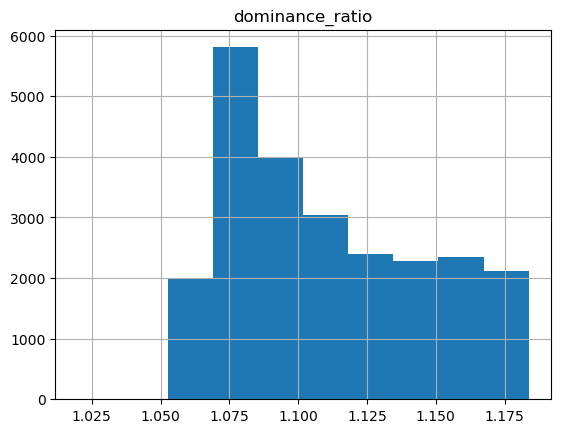

In [199]:
df2.hist("dominance_ratio")

In [200]:
df2["dominant_axis"].value_counts()

dominant_axis
j    9558
k    8332
i    6110
Name: count, dtype: int64

In [210]:
df2['dominance_ratio']

0        1.021027
1        1.144890
2        1.145675
3        1.145068
4        1.145751
           ...   
24007    1.084945
24008    1.075628
24009    1.080612
24010    1.074643
24011    1.086449
Name: dominance_ratio, Length: 24012, dtype: float64

In [214]:
RESOLUTION_STATS[5]

{'num_cells': 168072,
 'area_km2': 3034.8403744,
 'area_m2': 3034840374.4,
 'cls_km': 62.1617764,
 'cls_m': 62161.7764}

In [235]:
# df2[]  mean_d_geom mean_d_k dominant_axis dominance_ratio

dist_cls_ratio_list = []
counter = 0

for idx, row in df2.iterrows():
    ijk = {'i': row['mean_d_i'], 'j': row['mean_d_j'], 'k': row['mean_d_k']}
    others = ["i", "j", "k"]
    
    dom = row['dominant_axis']
    gmean = row['mean_d_geom']
    bigmean = ijk.get(dom, gmean)

    cls_m = RESOLUTION_STATS[5]['cls_m']
    stretch = row['dominance_ratio']

    dists_ratio = max(gmean, cls_m) / min(gmean, cls_m)
    print(dists_ratio)
    print(gmean)
    print(bigmean)
    dist_cls_ratio_list.append(dists_ratio)

    counter=counter+1

    # if dists_ratio >= 1.01:
    if counter > 10:
        break

    

# df2["dist_cls_ratio"] = dist_cls_ratio_list

1.0577166632911628
58769.78075260636
58769.78075260636
1.0429451129388836
59602.155117095484
65280.39217436515
1.042899272261629
59604.774932094944
65312.602392684516
1.0429398232745368
59602.45741200059
65286.964392115326
1.042886765083811
59605.48976283577
65316.90055918054
1.0429092102672628
59604.206951120905
65300.04146432765
1.0428510621841942
59607.530407847094
66339.02681986027
1.0416283277938383
59677.501793425894
66730.05150413087
1.0414909990195813
59685.370741097766
66659.88933559351
1.0423009473351885
59638.99059952567
66289.34058708687
1.0411430826617185
59705.31566235954
65806.935522732


<Axes: >

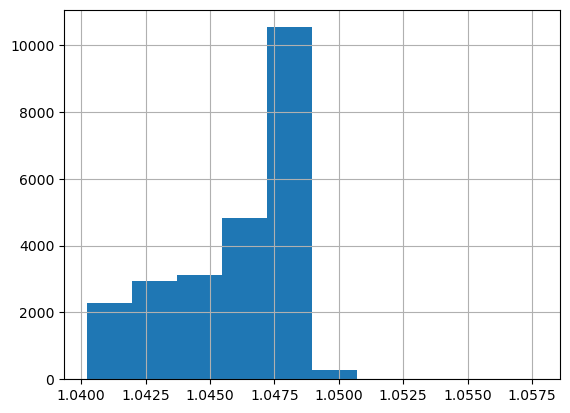

In [226]:
df2["dist_cls_ratio"].hist()

In [227]:

import os
import shapely
import numpy as np
import pandas as pd
from pyproj import Geod
import geopandas as gpd

from dggrid4py import DGGRIDv8, geoseries_to_geodetic

import z7py.z7 as z7
from z7py.z7 import RESOLUTION_STATS

from z7_xarray_paper.config import (
    IGEO7_META,
    DATA_OUTPUT,
    clipper_scale_factor_for,
)

INVALID = np.uint64(0xFFFFFFFFFFFFFFFF)
LEVEL = 3

In [228]:
os.environ["DGGRID_PATH"]

'/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/bin/dggrid'

In [217]:
def enumerate_global_cells(level: int) -> gpd.GeoDataFrame:
    """All cells at `level` globally via WHOLE_EARTH mode.

    Applies authalic-to-geodetic conversion to centroids.
    """
    if "DGGRID_PATH" not in os.environ:
        raise SystemExit("DGGRID_PATH not set")
    cache_dir = os.path.expanduser("~/.cache/_z7_global_sweep")
    os.makedirs(cache_dir, exist_ok=True)
    dggrid = DGGRIDv8(os.environ["DGGRID_PATH"], working_dir=cache_dir, silent=True)

    expected = RESOLUTION_STATS[level]["num_cells"]
    print(f"[enum] requesting level={level} via WHOLE_EARTH (expected {expected:,} cells) ...")

    df_all = dggrid.grid_cell_centroids_for_extent(
        "IGEO7", level,
        clip_geom=None,    # triggers WHOLE_EARTH mode
        **IGEO7_META,
    )

    # Apply authalic to geodetic conversion
    df_all.geometry = geoseries_to_geodetic(df_all.geometry)
    df_all.crs = 4326

    df_all["z7int"] = df_all["name"].apply(int, base=16).astype(np.uint64)
    df_all["z7_string"] = df_all["z7int"].apply(z7.index_to_z7string)
    df_all["lon"] = df_all.geometry.x.astype(np.float64)
    df_all["lat"] = df_all.geometry.y.astype(np.float64)
    df_all = df_all[["z7_string", "z7int", "lon", "lat", "geometry"]].drop_duplicates(subset="z7_string").reset_index(drop=True)

    print(f"[enum] got {len(df_all):,} cells")
    if len(df_all) != expected:
        print(f"[enum] WARNING: cell count mismatch (got {len(df_all):,}, expected {expected:,})")
    return df_all

In [218]:
gdf3 = enumerate_global_cells(4)

[enum] requesting level=4 via WHOLE_EARTH (expected 24,012 cells) ...


/Users/akmoch/dev/build/igeo7_z7_xarray_paper/.pixi/envs/default/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver FlatGeobuf does not support open option DRIVER
  return ogr_read(


[enum] got 24,012 cells


In [229]:
gdf4 = gdf3.set_index("z7int").join(df2.set_index("parent3"))
gdf4.sample(5)

,z7_string,lon,lat,geometry,n,mean_d_k,std_d_k,mean_d_j,std_d_j,mean_d_i,std_d_i,mean_d_geom,mean_squeeze,min_squeeze,modal_squeezed_axis,dominance_ratio,dominant_axis,dominance_flag,dist_cls_ratio
z7int,,,,,,,,,,,,,,,,,,,
2775061795390357503,023202,-51.366341,50.845466,POINT (-51.36634 50.84547),7,62608.104133,33.023828,58689.262394,26.465671,56756.268876,33.962805,59301.766259,0.906533,0.905360,i,1.084635,k,high,1.048228
5357313231733915647,045130,30.223751,-23.707479,POINT (30.22375 -23.70748),7,58463.948494,39.723874,56929.446471,31.250892,62657.956009,39.973818,59301.685450,0.908575,0.907403,j,1.085989,i,high,1.048230
10119025412748083199,086155,34.173769,-56.079109,POINT (34.17377 -56.07911),7,54499.262057,112.238963,65022.865291,178.393307,59491.265650,44.354742,59516.296222,0.838165,0.832662,k,1.140847,j,high,1.044450
10682819791099527167,092100,82.694955,-14.754650,POINT (82.69495 -14.75465),7,63903.654909,161.907315,57512.188452,51.618645,56969.883629,66.833552,59380.399599,0.891504,0.887011,i,1.116396,k,high,1.046840
4091801736442806271,034310,-11.392073,-10.284977,POINT (-11.39207 -10.28498),7,65368.264193,219.767853,59609.663546,40.725664,54209.375423,126.750914,59555.009799,0.829305,0.822842,i,1.148635,k,high,1.043771


<Axes: >

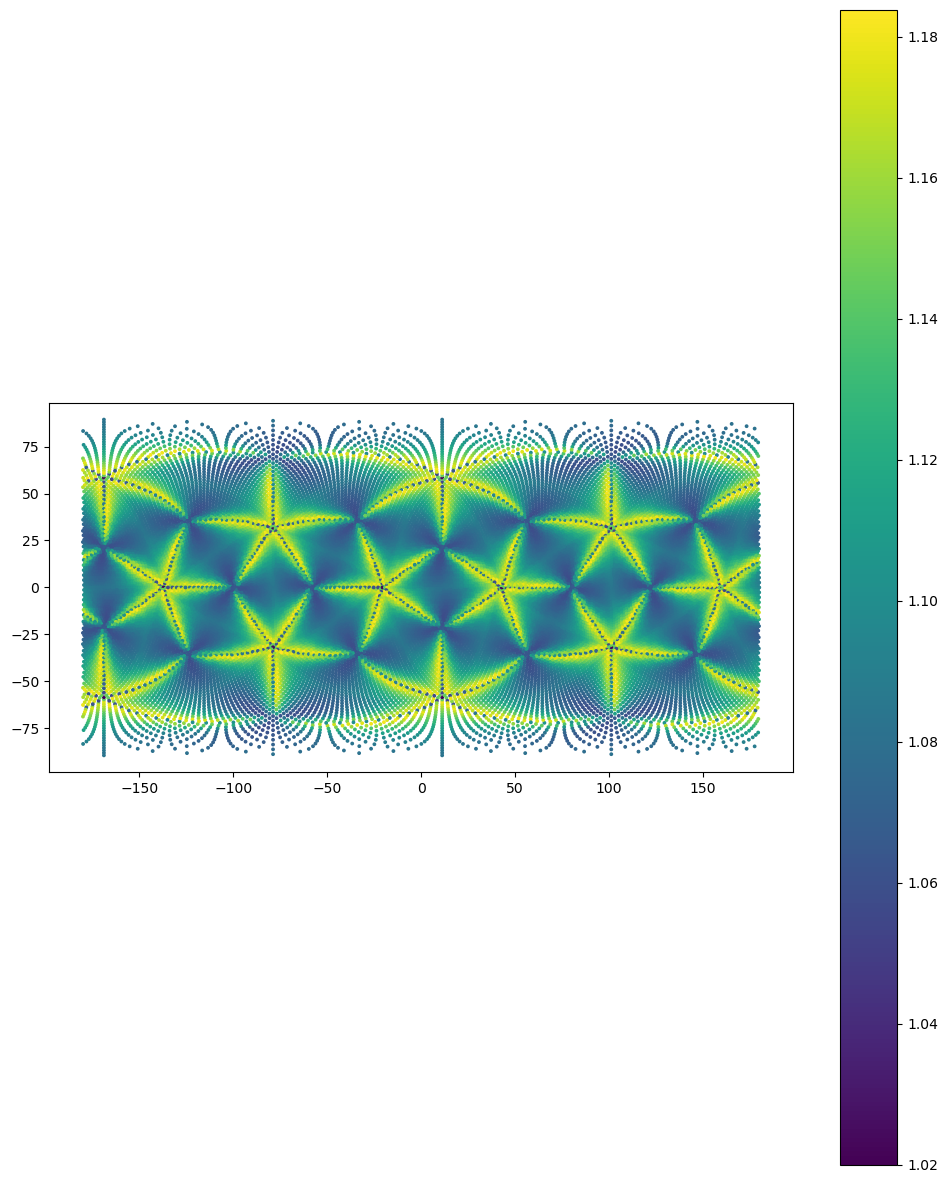

In [230]:
gdf4.plot(figsize=(12, 15), column="dominance_ratio", legend=True, markersize=3)

<Axes: >

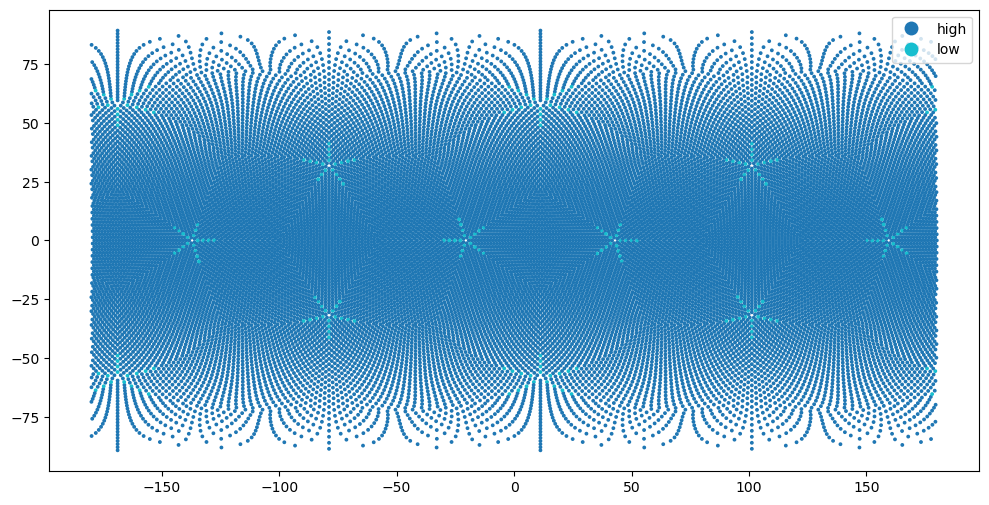

In [231]:
gdf4.plot(figsize=(12, 15), column="dominance_flag", legend=True, markersize=3)

<Axes: >

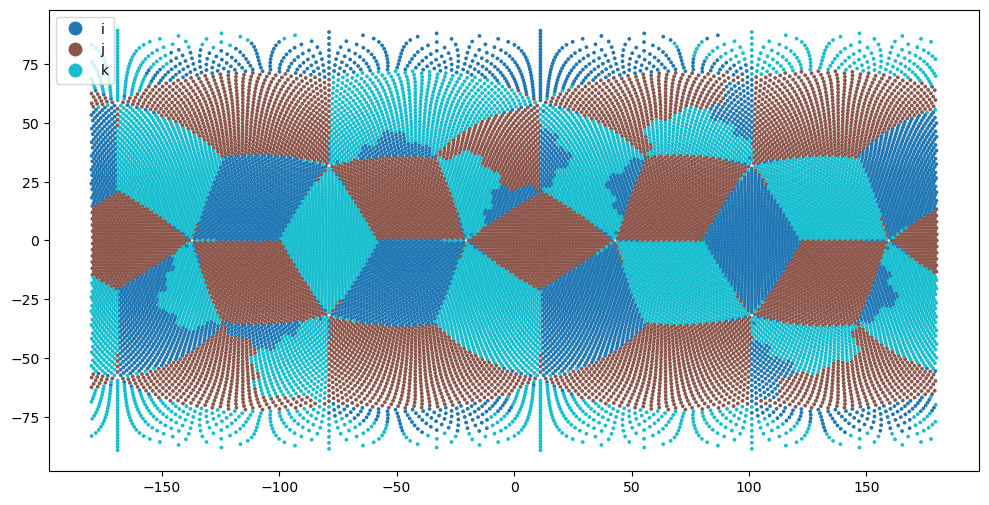

In [232]:

gdf4.plot(figsize=(12, 15), column="dominant_axis", legend=True, markersize=3)

<Axes: >

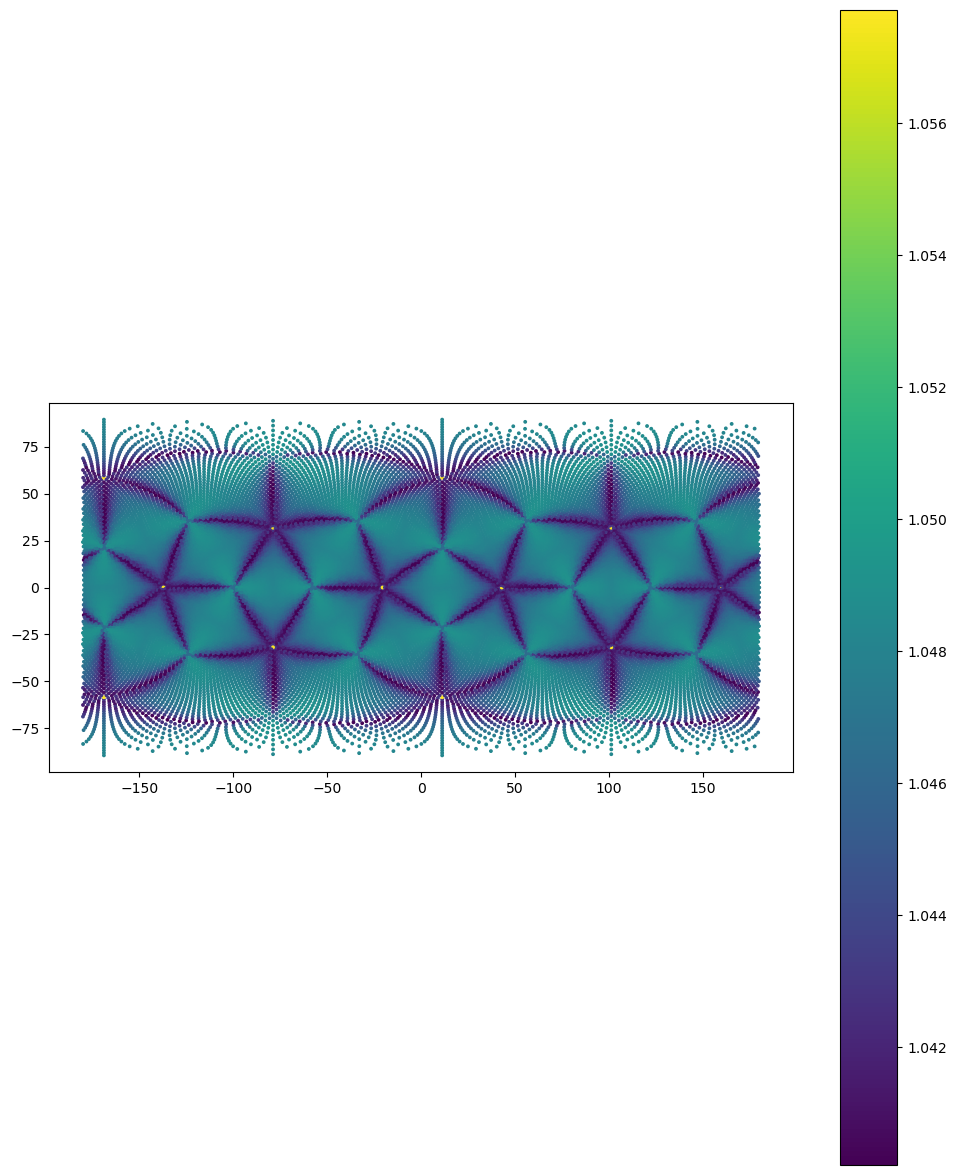

In [233]:
gdf4.plot(figsize=(12, 15), column="dist_cls_ratio", legend=True, markersize=3)

In [243]:
import numpy as np

def calculate_centroid_distance(cls: float) -> float:
    """
    Calculates the default distance between centroids of adjacent regular 
    hexagons given the Characteristic Length Scale (cls).
    
    Derivation:
    Area of circle = Area of hexagon -> pi*(cls/2)^2 = (3*sqrt(3)/2)*s^2
    s = cls * sqrt(pi / (6*sqrt(3)))
    d = s * sqrt(3) -> d = cls * sqrt(pi / (2*sqrt(3)))
    """
    # The derived mathematical constant
    factor = np.sqrt(np.pi / (2 * np.sqrt(3)))
    
    return cls * factor

# --- Example Usage ---
# Calculate just the factor to verify the ~0.9523 value
derived_factor = np.sqrt(np.pi / (2 * np.sqrt(3)))
print(f"The exact scaling factor is: {derived_factor:.4f}")

# Apply it to a hypothetical cls value
sample_cls = 100.0
sample_d = calculate_centroid_distance(sample_cls)
print(f"For a cls of {sample_cls}, the default centroid distance is: {sample_d:.4f}")

level_test = 4 
cls_m_4 = RESOLUTION_STATS[level_test]["cls_m"]

cls_m_4_d = calculate_centroid_distance(cls_m_4)
print(f"For a cls_m at level {level_test} of {cls_m_4}, the default centroid distance is: {cls_m_4_d:.4f}")

level_test = 5
cls_m_4 = RESOLUTION_STATS[level_test]["cls_m"]

cls_m_4_d = calculate_centroid_distance(cls_m_4)
print(f"For a cls_m at level {level_test} of {cls_m_4}, the default centroid distance is: {cls_m_4_d:.4f}")

The exact scaling factor is: 0.9523
For a cls of 100.0, the default centroid distance is: 95.2313
For a cls_m at level 4 of 164465.5799, the default centroid distance is: 156622.6780
For a cls_m at level 5 of 62161.7764, the default centroid distance is: 59197.4558


164465.5799

In [253]:
dist_lookup = df2.rename(columns={"parent3":"cell_ids"}).set_index("cell_ids", drop=True)[["n", "mean_d_k", "mean_d_j", "mean_d_i", "mean_d_geom"]].copy()

In [254]:
dist_lookup.to_parquet("../data/working/dist_lookup_level4.parquet")

In [255]:
dist_lookup

,n,mean_d_k,mean_d_j,mean_d_i,mean_d_geom
cell_ids,,,,,
281474976710655,5,58271.581595,59667.066365,58605.021242,58769.780753
562949953421311,7,54513.827664,65280.392174,59524.026467,59602.155117
1125899906842623,7,65312.602393,59497.701041,54518.200086,59604.774932
1407374883553279,7,65286.964392,59505.236380,54526.354786,59602.457412
1688849860263935,7,59516.146890,54499.689620,65316.900559,59605.489763
...,...,...,...,...,...
13669269293999587327,7,57455.971203,62607.115611,57954.692864,59294.639187
13669550768976297983,7,57440.994554,62228.814380,58265.907517,59275.563042
13669832243953008639,7,57327.083542,62432.214502,58222.693891,59286.177013


In [252]:
Z7.get_resolution(281474976710655)

4

In [256]:
import numpy as np

class HexGridDistortionModel:
    def __init__(self, empirical_data: dict):
        """
        Initializes the model by pre-computing the scaling weights 
        for every region to ensure lightning-fast lookups later.
        """
        # The exact geometric constant derived earlier (~0.9523)
        self.base_factor = np.sqrt(np.pi / (2 * np.sqrt(3)))
        
        # This will hold our pre-calculated weights
        self.region_weights = {}
        
        # Pre-compute weights on startup
        for region_id, measurements in empirical_data.items():
            geom_mean = measurements['mean_d_geom']
            
            self.region_weights[region_id] = {
                'w_k': measurements['mean_d_k'] / geom_mean,
                'w_j': measurements['mean_d_j'] / geom_mean,
                'w_i': measurements['mean_d_i'] / geom_mean
            }

    def get_neighbor_distances(self, region_key: str, cls: float) -> dict:
        """
        Returns the actual anisotropic distances to neighbors for a given cls.
        """
        # 1. Calculate the theoretical perfectly-regular distance
        base_d = cls * self.base_factor
        
        # 2. Fetch the pre-computed stretch/squeeze weights
        weights = self.region_weights.get(region_key)
        
        if not weights:
            # Fallback: if region isn't in lookup, assume a perfect hexagon
            return {'d_k': base_d, 'd_j': base_d, 'd_i': base_d}
            
        # 3. Apply the weights to the base distance
        return {
            'd_k': base_d * weights['w_k'],
            'd_j': base_d * weights['w_j'],
            'd_i': base_d * weights['w_i']
        }

# ==========================================
# Example Usage
# ==========================================

# 1. Your raw empirical data (perhaps loaded from a CSV/Database)
raw_measurements = {
    "Region_Alpha": {
        "mean_d_k": 62608.104133,
        "mean_d_j": 58689.262394,
        "mean_d_i": 56756.268876,
        "mean_d_geom": 59301.766259
    },
    "Region_Beta": {
        # Hypothetical region that is squeezed differently
        "mean_d_k": 58000.0,
        "mean_d_j": 61000.0,
        "mean_d_i": 59000.0,
        "mean_d_geom": 59316.5 
    }
}

# 2. Initialize the model once
grid_model = HexGridDistortionModel(raw_measurements)

# 3. Query it as fast and as often as you need
sample_cls = 100.0
alpha_distances = grid_model.get_neighbor_distances("Region_Alpha", sample_cls)

print(f"Distances for Region Alpha (cls={sample_cls}):")
print(f"  Axis K: {alpha_distances['d_k']:.4f}")
print(f"  Axis J: {alpha_distances['d_j']:.4f}")
print(f"  Axis I: {alpha_distances['d_i']:.4f}")

Distances for Region Alpha (cls=100.0):
  Axis K: 100.5408
  Axis J: 94.2477
  Axis I: 91.1435


In [258]:
import pandas as pd

# Load the parquet file and instantly convert it to the nested dict format our model expects
# Assuming your parquet file has a 'region_key' column and the 4 mean columns
empirical_data = pd.read_parquet('../data/working/dist_lookup_level4.parquet').to_dict('index')

# Initialize the model
grid_model = HexGridDistortionModel(empirical_data)

In [260]:
# level_test = 5
cls_m_4 = RESOLUTION_STATS[level_test]["cls_m"]

alpha_distances = grid_model.get_neighbor_distances(13670113718929719295, cls_m_4)

print(f"Distances for Region 13670113718929719295 {Z7.index_to_z7string(13670113718929719295)} (cls={cls_m_4}):")
print(f"  Axis K: {alpha_distances['d_k']:.4f}")
print(f"  Axis J: {alpha_distances['d_j']:.4f}")
print(f"  Axis I: {alpha_distances['d_i']:.4f}")

Distances for Region 13670113718929719295 116665 (cls=62161.7764):
  Axis K: 57213.2154
  Axis J: 62109.8893
  Axis I: 58378.4391


In [261]:
Z7.get_base_cell(13670113718929719295)

11